# 06 - Dashboard Data Prep and Campaign ROI Simulation

In this notebook, we prepare final dashboard-ready datasets and simulate the business impact of retention campaigns.

The goal is to convert the customer segmentation and next-best-action outputs into:
- KPI summary tables
- segment-level dashboard tables
- action-level dashboard tables
- geography-level dashboard tables
- campaign ROI simulation

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [2]:
# Connecting notebook to project folders

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = Path("/content/drive/MyDrive/LoyaltyRadar")

PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DIR = BASE_DIR / "data" / "outputs"
FIGURE_DIR = BASE_DIR / "reports" / "figures"
DASHBOARD_DIR = BASE_DIR / "dashboard" / "data"

DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [3]:
# Loading final customer segments and campaign table

segments = pd.read_csv(PROCESSED_DIR / "05_customer_segments_actions.csv")
campaign_table = pd.read_csv(OUTPUT_DIR / "05_campaign_table.csv")

print("Segments shape:", segments.shape)
print("Campaign table shape:", campaign_table.shape)
print("Unique customers:", segments["loyalty_number"].nunique())

display(segments.head())

Segments shape: (16737, 62)
Campaign table shape: (16737, 22)
Unique customers: 16737


,loyalty_number,target_churn,behavioral_churn,formal_churn,churn_status_group,months_present,total_flights,active_months,inactive_months,active_month_rate,avg_flights_per_active_month,total_distance,flights_last_3m,flights_last_6m,points_accumulated_last_6m,points_redeemed_last_6m,inactive_last_3m,inactive_last_6m,flights_first_half_2018,flights_second_half_2018,flight_drop,flight_drop_pct,sharp_drop_flag,q1_flights,q2_flights,q3_flights,q4_flights,seasonality_ratio,seasonal_flag,total_points_accumulated,total_points_redeemed,redemption_months,has_redeemed,redemption_rate,points_collector_flag,clv,clv_tier,high_value_flag,premium_value_flag,loyalty_value_at_risk,retention_priority_score,priority_band,loyalty_card,province,city,gender,education,salary_imputed,salary_missing,enrollment_type,premium_drifter_flag,points_collector_at_risk_flag,travel_break_risk_flag,seasonal_risk_flag,silent_risk_flag,primary_segment,recovery_potential_score,at_risk_flag,recovery_potential_score_v2,recovery_potential_band,next_best_action,next_best_action_v2
0,100018,0,0,0,Healthy Active,24,46,18,6,0.750000,2.555556,81190,10,17,36377.0,385,0,0,5.0,17.0,-12.0,-2.400000,0,9,3,16,18,0.391304,0,81190.0,1513,3,True,0.018635,1,7919.20,High Value,1,0,0.0,10,Low Priority,Aurora,Alberta,Edmonton,Female,Bachelor,92552.0,0,Standard,0,0,0,0,0,Healthy / Monitor,80,0,0,No Recovery Action Needed,Monitor only,Monitor only
1,100102,0,0,0,Healthy Active,24,51,17,7,0.708333,3.000000,68918,11,17,18795.0,0,0,0,9.0,17.0,-8.0,-0.888889,0,10,10,13,18,0.352941,0,68918.0,1195,2,True,0.017339,1,2887.74,Low Value,0,0,0.0,10,Low Priority,Nova,Ontario,Toronto,Male,College,73455.0,1,Standard,0,0,0,0,0,Healthy / Monitor,60,0,0,No Recovery Action Needed,Monitor only,Monitor only
2,100140,0,0,0,Healthy Active,24,47,17,7,0.708333,2.764706,72856,3,11,20488.0,0,0,0,14.0,11.0,3.0,0.214286,0,9,13,15,10,0.319149,0,72856.0,593,1,True,0.008139,1,2838.07,Low Value,0,0,0.0,10,Low Priority,Nova,British Columbia,Dawson Creek,Female,College,73455.0,1,Standard,0,0,0,0,0,Healthy / Monitor,60,0,0,No Recovery Action Needed,Monitor only,Monitor only
3,100214,0,0,0,Healthy Active,24,22,9,15,0.375000,2.444444,38236,3,9,14321.0,0,0,0,3.0,9.0,-6.0,-2.000000,0,3,2,8,9,0.409091,0,38236.0,861,2,True,0.022518,0,4170.57,Mid Value,0,0,0.0,0,Low Priority,Star,British Columbia,Vancouver,Male,Bachelor,63253.0,0,Standard,0,0,0,0,0,Healthy / Monitor,45,0,0,No Recovery Action Needed,Monitor only,Monitor only
4,100272,0,0,0,Healthy Active,24,37,13,11,0.541667,2.846154,54997,4,9,16412.0,0,0,0,8.0,9.0,-1.0,-0.125000,0,7,15,7,8,0.405405,0,54997.0,1007,2,True,0.018310,1,6622.05,High Value,1,0,0.0,10,Low Priority,Star,Ontario,Toronto,Female,Bachelor,91163.0,0,Standard,0,0,0,0,0,Healthy / Monitor,80,0,0,No Recovery Action Needed,Monitor only,Monitor only


In [4]:
# Creating dashboard KPI summary

total_customers = segments["loyalty_number"].nunique()
total_clv = segments["clv"].sum()
total_value_at_risk = segments["loyalty_value_at_risk"].sum()

behavioral_churn_customers = segments["behavioral_churn"].sum()
formal_churn_customers = segments["formal_churn"].sum()

premium_drifters = segments["premium_drifter_flag"].sum()
silent_risk_customers = segments["silent_risk_flag"].sum()

high_priority_customers = segments[
    segments["priority_band"].isin(["High Priority", "Critical Priority"])
]["loyalty_number"].nunique()

actionable_customers = segments[
    segments["next_best_action_v2"] != "Monitor only"
]["loyalty_number"].nunique()

kpi_summary = pd.DataFrame({
    "metric": [
        "Total Customers",
        "Total CLV",
        "Total Loyalty Value at Risk",
        "Value at Risk Share (%)",
        "Behavioral Churn Customers",
        "Formal Churn Customers",
        "Premium Drifters",
        "Silent Risk Customers",
        "High Priority Customers",
        "Actionable Customers"
    ],
    "value": [
        total_customers,
        round(total_clv, 2),
        round(total_value_at_risk, 2),
        round(total_value_at_risk / total_clv * 100, 2),
        behavioral_churn_customers,
        formal_churn_customers,
        premium_drifters,
        silent_risk_customers,
        high_priority_customers,
        actionable_customers
    ]
})

display(kpi_summary)

,metric,value
0,Total Customers,1.673700e+04
1,Total CLV,1.337102e+08
2,Total Loyalty Value at Risk,2.006246e+07
3,Value at Risk Share (%),1.500000e+01
4,Behavioral Churn Customers,2.469000e+03
5,Formal Churn Customers,2.067000e+03
6,Premium Drifters,6.130000e+02
7,Silent Risk Customers,7.270000e+02
8,High Priority Customers,2.537000e+03
9,Actionable Customers,2.469000e+03


Observation:
The KPI summary converts the analytical results into dashboard-ready business metrics. The customer base contains 16,737 customers with total CLV of around 133.71 million. Around 20.06 million CLV, or 15% of total value, is currently associated with behaviorally churned customers. The dashboard also identifies 2,469 actionable customers, including 613 Premium Drifters and 727 Silent Risk customers, giving the business a clear retention target size.

In [5]:
# Saving KPI summary for dashboard

kpi_summary.to_csv(
    DASHBOARD_DIR / "dashboard_kpi_summary.csv",
    index=False
)

print("Saved dashboard KPI summary.")

Saved dashboard KPI summary.


In [6]:
# Creating segment-level dashboard table

segment_dashboard = (
    segments
    .groupby("primary_segment")
    .agg(
        customers=("loyalty_number", "count"),
        total_clv=("clv", "sum"),
        total_value_at_risk=("loyalty_value_at_risk", "sum"),
        avg_clv=("clv", "mean"),
        avg_priority_score=("retention_priority_score", "mean"),
        avg_recovery_score=("recovery_potential_score_v2", "mean"),
        behavioral_churn_rate=("behavioral_churn", "mean"),
        formal_churn_rate=("formal_churn", "mean")
    )
    .reset_index()
)

segment_dashboard["value_at_risk_share_pct"] = (
    segment_dashboard["total_value_at_risk"] /
    segment_dashboard["total_value_at_risk"].sum() * 100
)

segment_dashboard = segment_dashboard.round(3).sort_values(
    "total_value_at_risk",
    ascending=False
)

display(segment_dashboard)

,primary_segment,customers,total_clv,total_value_at_risk,avg_clv,avg_priority_score,avg_recovery_score,behavioral_churn_rate,formal_churn_rate,value_at_risk_share_pct
2,Premium Drifter,613,1.056748e+07,10567476.08,17238.950,72.178,49.600,1.000,0.719,52.673
0,Healthy / Monitor,15258,1.187471e+08,5099352.57,7782.610,13.230,0.939,0.065,0.086,25.417
4,Silent Risk,555,2.854310e+06,2854309.61,5142.900,51.532,34.207,1.000,0.000,14.227
5,Travel Break Risk,162,8.145281e+05,814528.12,5027.951,66.327,17.747,1.000,1.000,4.060
3,Seasonal Risk,146,7.139016e+05,713901.55,4889.737,55.000,10.274,1.000,1.000,3.558
1,Points Collector at Risk,3,1.288994e+04,12889.94,4296.647,60.000,35.000,1.000,1.000,0.064


Observation:
The segment dashboard shows that Premium Drifters are the most important retention segment, contributing around 52.67% of total value at risk despite having only 613 customers. Silent Risk customers contribute around 14.23% of value at risk and have zero formal churn, making them useful for proactive retention. This table helps identify which customer segments should be prioritized in the dashboard.

In [7]:
# Saving segment dashboard table

segment_dashboard.to_csv(
    DASHBOARD_DIR / "dashboard_segment_summary.csv",
    index=False
)

print("Saved segment dashboard table.")

Saved segment dashboard table.


In [8]:
# Creating action-level dashboard table

action_dashboard = (
    segments
    .groupby("next_best_action_v2")
    .agg(
        customers=("loyalty_number", "count"),
        total_clv=("clv", "sum"),
        total_value_at_risk=("loyalty_value_at_risk", "sum"),
        avg_clv=("clv", "mean"),
        avg_priority_score=("retention_priority_score", "mean"),
        avg_recovery_score=("recovery_potential_score_v2", "mean"),
        behavioral_churn_rate=("behavioral_churn", "mean"),
        formal_churn_rate=("formal_churn", "mean")
    )
    .reset_index()
)

action_dashboard["value_at_risk_share_pct"] = (
    action_dashboard["total_value_at_risk"] /
    action_dashboard["total_value_at_risk"].sum() * 100
)

action_dashboard = action_dashboard.round(3).sort_values(
    "total_value_at_risk",
    ascending=False
)

display(action_dashboard)

,next_best_action_v2,customers,total_clv,total_value_at_risk,avg_clv,avg_priority_score,avg_recovery_score,behavioral_churn_rate,formal_churn_rate,value_at_risk_share_pct
4,Personalized premium win-back offer,613,1.056748e+07,10567476.08,17238.950,72.178,49.600,1.0,0.719,52.673
2,Low-cost automated reactivation,990,5.099353e+06,5099352.57,5150.861,50.000,8.697,1.0,1.000,25.417
0,Early retention call or targeted offer,216,1.532881e+06,1532880.98,7096.671,53.056,47.731,1.0,0.000,7.641
1,Gentle re-engagement reminder,339,1.321429e+06,1321428.63,3898.020,50.560,25.590,1.0,0.000,6.587
7,Travel pattern break alert with limited-time o...,162,8.145281e+05,814528.12,5027.951,66.327,17.747,1.0,1.000,4.060
6,Seasonal timing reminder before peak travel pe...,146,7.139016e+05,713901.55,4889.737,55.000,10.274,1.0,1.000,3.558
5,Points redemption nudge,3,1.288994e+04,12889.94,4296.647,60.000,35.000,1.0,1.000,0.064
3,Monitor only,14268,1.136477e+08,0.00,7965.216,10.678,0.401,0.0,0.023,0.000


In [9]:
# Saving action dashboard table

action_dashboard.to_csv(
    DASHBOARD_DIR / "dashboard_action_summary.csv",
    index=False
)

print("Saved action dashboard table.")

Saved action dashboard table.


Observation:
The action dashboard converts customer risk into campaign-level business actions. Personalized premium win-back offers cover only 613 customers but represent around 52.67% of total value at risk, making them the most important high-value campaign. Low-cost automated reactivation covers 990 customers and around 25.42% of value at risk, making it suitable for scalable retention. Monitor Only customers have zero value at risk and zero behavioral churn, confirming that the final action logic does not ignore inactive customers.

In [10]:
# Creating geography-level dashboard table

geo_dashboard = (
    segments
    .groupby(["province", "city"])
    .agg(
        customers=("loyalty_number", "count"),
        total_clv=("clv", "sum"),
        total_value_at_risk=("loyalty_value_at_risk", "sum"),
        avg_clv=("clv", "mean"),
        behavioral_churn_rate=("behavioral_churn", "mean"),
        formal_churn_rate=("formal_churn", "mean"),
        avg_priority_score=("retention_priority_score", "mean")
    )
    .reset_index()
)

geo_dashboard["value_at_risk_share_pct"] = (
    geo_dashboard["total_value_at_risk"] /
    geo_dashboard["total_value_at_risk"].sum() * 100
)

geo_dashboard = geo_dashboard.round(3).sort_values(
    "total_value_at_risk",
    ascending=False
)

display(geo_dashboard.head(20))

,province,city,customers,total_clv,total_value_at_risk,avg_clv,behavioral_churn_rate,formal_churn_rate,avg_priority_score,value_at_risk_share_pct
20,Ontario,Toronto,3351,26346160.74,3823892.71,7862.179,0.143,0.123,17.123,19.060
6,British Columbia,Vancouver,2582,20260733.36,2984049.50,7846.915,0.143,0.119,17.066,14.874
24,Quebec,Montreal,2059,17127656.39,2775498.02,8318.434,0.150,0.127,17.982,13.834
10,Manitoba,Winnipeg,658,5307793.70,991984.85,8066.556,0.172,0.152,18.488,4.944
21,Ontario,Trenton,486,3784836.60,731036.79,7787.730,0.169,0.138,18.549,3.644
9,British Columbia,Whistler,582,5103562.57,689596.21,8769.008,0.139,0.119,18.213,3.437
14,Nova Scotia,Halifax,518,4135351.86,620526.84,7983.305,0.154,0.112,17.635,3.093
2,Alberta,Edmonton,486,3849297.98,607138.87,7920.366,0.136,0.123,16.965,3.026
25,Quebec,Quebec City,485,3830487.84,582365.70,7897.913,0.144,0.105,17.546,2.903
17,Ontario,Ottawa,509,4089264.93,545117.08,8033.919,0.132,0.106,16.670,2.717


In [11]:
# Saving geography dashboard table

geo_dashboard.to_csv(
    DASHBOARD_DIR / "dashboard_geo_summary.csv",
    index=False
)

print("Saved geography dashboard table.")

Saved geography dashboard table.


Observation:
The geography dashboard shows that Toronto, Vancouver, and Montreal contribute the highest value at risk, mainly because they have the largest customer bases. Together, these three cities account for a large share of risky CLV, making them useful starting points for regional campaign planning. Smaller cities such as Winnipeg and Trenton show higher behavioral churn rates, so they may also deserve attention despite having fewer customers.

In [12]:
# Creating province-level dashboard table

province_dashboard = (
    segments
    .groupby("province")
    .agg(
        customers=("loyalty_number", "count"),
        total_clv=("clv", "sum"),
        total_value_at_risk=("loyalty_value_at_risk", "sum"),
        avg_clv=("clv", "mean"),
        behavioral_churn_rate=("behavioral_churn", "mean"),
        formal_churn_rate=("formal_churn", "mean"),
        avg_priority_score=("retention_priority_score", "mean")
    )
    .reset_index()
)

province_dashboard["value_at_risk_share_pct"] = (
    province_dashboard["total_value_at_risk"] /
    province_dashboard["total_value_at_risk"].sum() * 100
)

province_dashboard = province_dashboard.round(3).sort_values(
    "total_value_at_risk",
    ascending=False
)

display(province_dashboard)

,province,customers,total_clv,total_value_at_risk,avg_clv,behavioral_churn_rate,formal_churn_rate,avg_priority_score,value_at_risk_share_pct
6,Ontario,5404,42765917.20,6407110.26,7913.752,0.148,0.125,17.422,31.936
1,British Columbia,4409,35244344.15,5168494.67,7993.727,0.142,0.118,17.421,25.762
8,Quebec,3300,26931155.73,4154863.61,8160.956,0.151,0.125,17.938,20.710
0,Alberta,969,7512452.21,1154774.97,7752.789,0.149,0.126,17.410,5.756
2,Manitoba,658,5307793.70,991984.85,8066.556,0.172,0.152,18.488,4.944
3,New Brunswick,636,5186060.18,661859.18,8154.183,0.134,0.105,16.816,3.299
5,Nova Scotia,518,4135351.86,620526.84,7983.305,0.154,0.112,17.635,3.093
9,Saskatchewan,409,3303237.17,454497.59,8076.374,0.149,0.122,17.641,2.265
4,Newfoundland,258,2070470.73,276301.95,8025.080,0.151,0.147,17.597,1.377
7,Prince Edward Island,66,508496.24,119513.10,7704.488,0.227,0.167,20.227,0.596


Observation:
The province dashboard shows that Ontario, British Columbia, and Quebec together account for around 78.41% of total value at risk. This suggests that regional retention planning should first focus on these provinces. Prince Edward Island shows the highest behavioral churn rate, but it has a very small customer base, so this result should be interpreted carefully.

In [13]:
# Saving province dashboard table

province_dashboard.to_csv(
    DASHBOARD_DIR / "dashboard_province_summary.csv",
    index=False
)

print("Saved province dashboard table.")

Saved province dashboard table.


In [14]:
# Creating ROI simulation assumptions

roi_assumptions = pd.DataFrame({
    "next_best_action_v2": [
        "Personalized premium win-back offer",
        "Early retention call or targeted offer",
        "Gentle re-engagement reminder",
        "Low-cost automated reactivation",
        "Travel pattern break alert with limited-time offer",
        "Seasonal timing reminder before peak travel period",
        "Points redemption nudge"
    ],
    "expected_recovery_rate": [
        0.18,
        0.15,
        0.08,
        0.05,
        0.07,
        0.06,
        0.05
    ],
    "cost_per_customer": [
        120,
        80,
        15,
        5,
        25,
        10,
        8
    ]
})

display(roi_assumptions)

,next_best_action_v2,expected_recovery_rate,cost_per_customer
0,Personalized premium win-back offer,0.18,120
1,Early retention call or targeted offer,0.15,80
2,Gentle re-engagement reminder,0.08,15
3,Low-cost automated reactivation,0.05,5
4,Travel pattern break alert with limited-time o...,0.07,25
5,Seasonal timing reminder before peak travel pe...,0.06,10
6,Points redemption nudge,0.05,8


In [15]:
# Simulating campaign ROI by action

roi_base = action_dashboard[
    action_dashboard["next_best_action_v2"] != "Monitor only"
].copy()

roi_simulation = roi_base.merge(
    roi_assumptions,
    on="next_best_action_v2",
    how="left"
)

roi_simulation["expected_recovered_value"] = (
    roi_simulation["total_value_at_risk"] *
    roi_simulation["expected_recovery_rate"]
)

roi_simulation["campaign_cost"] = (
    roi_simulation["customers"] *
    roi_simulation["cost_per_customer"]
)

roi_simulation["expected_net_value"] = (
    roi_simulation["expected_recovered_value"] -
    roi_simulation["campaign_cost"]
)

roi_simulation["roi_multiple"] = (
    roi_simulation["expected_recovered_value"] /
    roi_simulation["campaign_cost"]
)

roi_simulation = roi_simulation.round(3).sort_values(
    "expected_net_value",
    ascending=False
)

display(roi_simulation)

,next_best_action_v2,customers,total_clv,total_value_at_risk,avg_clv,avg_priority_score,avg_recovery_score,behavioral_churn_rate,formal_churn_rate,value_at_risk_share_pct,expected_recovery_rate,cost_per_customer,expected_recovered_value,campaign_cost,expected_net_value,roi_multiple
0,Personalized premium win-back offer,613,10567476.08,10567476.08,17238.950,72.178,49.600,1.0,0.719,52.673,0.18,120,1902145.694,73560,1828585.694,25.858
1,Low-cost automated reactivation,990,5099352.57,5099352.57,5150.861,50.000,8.697,1.0,1.000,25.417,0.05,5,254967.629,4950,250017.629,51.509
2,Early retention call or targeted offer,216,1532880.98,1532880.98,7096.671,53.056,47.731,1.0,0.000,7.641,0.15,80,229932.147,17280,212652.147,13.306
3,Gentle re-engagement reminder,339,1321428.63,1321428.63,3898.020,50.560,25.590,1.0,0.000,6.587,0.08,15,105714.290,5085,100629.290,20.789
4,Travel pattern break alert with limited-time o...,162,814528.12,814528.12,5027.951,66.327,17.747,1.0,1.000,4.060,0.07,25,57016.968,4050,52966.968,14.078
5,Seasonal timing reminder before peak travel pe...,146,713901.55,713901.55,4889.737,55.000,10.274,1.0,1.000,3.558,0.06,10,42834.093,1460,41374.093,29.338
6,Points redemption nudge,3,12889.94,12889.94,4296.647,60.000,35.000,1.0,1.000,0.064,0.05,8,644.497,24,620.497,26.854


Observation:
The ROI simulation is assumption-based and should not be interpreted as actual campaign performance. Under the current assumptions, the personalized premium win-back campaign gives the highest expected net value because it targets high-CLV Premium Drifters. Low-cost automated reactivation has the highest ROI multiple because the campaign cost per customer is very low. This shows that LoyaltyRadar can support both high-value manual campaigns and scalable low-cost campaigns.

In [16]:
# Creating total ROI summary

total_campaign_customers = roi_simulation["customers"].sum()
total_campaign_cost = roi_simulation["campaign_cost"].sum()
total_expected_recovered_value = roi_simulation["expected_recovered_value"].sum()
total_expected_net_value = roi_simulation["expected_net_value"].sum()
overall_roi_multiple = total_expected_recovered_value / total_campaign_cost

roi_kpi_summary = pd.DataFrame({
    "metric": [
        "Campaign Customers",
        "Total Campaign Cost",
        "Expected Recovered Value",
        "Expected Net Value",
        "Overall ROI Multiple"
    ],
    "value": [
        total_campaign_customers,
        round(total_campaign_cost, 2),
        round(total_expected_recovered_value, 2),
        round(total_expected_net_value, 2),
        round(overall_roi_multiple, 2)
    ]
})

display(roi_kpi_summary)

,metric,value
0,Campaign Customers,2469.00
1,Total Campaign Cost,106409.00
2,Expected Recovered Value,2593255.32
3,Expected Net Value,2486846.32
4,Overall ROI Multiple,24.37


Observation:
The ROI KPI summary estimates the business impact of targeting all actionable customers. Under the current assumption-based simulation, 2,469 customers would be targeted at an estimated campaign cost of 106,409. The expected recovered value is around 2.59 million, giving an expected net value of around 2.49 million and an overall ROI multiple of 24.37x. These results should be treated as simulated business estimates, not actual campaign outcomes.

In [17]:
# Saving ROI simulation outputs

roi_assumptions.to_csv(
    DASHBOARD_DIR / "dashboard_roi_assumptions.csv",
    index=False
)

roi_simulation.to_csv(
    DASHBOARD_DIR / "dashboard_roi_simulation.csv",
    index=False
)

roi_kpi_summary.to_csv(
    DASHBOARD_DIR / "dashboard_roi_kpi_summary.csv",
    index=False
)

print("Saved ROI simulation outputs.")

Saved ROI simulation outputs.


Now we’ll compare:

Do Nothing
Random Targeting
LoyaltyRadar Targeting

In [18]:
# Comparing campaign targeting strategies

actionable_customers = segments[segments["behavioral_churn"] == 1].copy()
non_actionable_customers = segments[segments["behavioral_churn"] == 0].copy()

target_count = len(actionable_customers)

# Do Nothing strategy
do_nothing_recovered_value = 0
do_nothing_cost = 0
do_nothing_net_value = 0

# Random targeting strategy
random_target = segments.sample(
    n=target_count,
    random_state=42
)

random_value_at_risk = random_target["loyalty_value_at_risk"].sum()

random_recovery_rate = 0.08
random_cost_per_customer = 20

random_recovered_value = random_value_at_risk * random_recovery_rate
random_campaign_cost = target_count * random_cost_per_customer
random_net_value = random_recovered_value - random_campaign_cost

# LoyaltyRadar targeting strategy
loyaltyradar_recovered_value = total_expected_recovered_value
loyaltyradar_campaign_cost = total_campaign_cost
loyaltyradar_net_value = total_expected_net_value

strategy_comparison = pd.DataFrame({
    "strategy": [
        "Do Nothing",
        "Random Targeting",
        "LoyaltyRadar Targeting"
    ],
    "targeted_customers": [
        0,
        target_count,
        target_count
    ],
    "value_at_risk_targeted": [
        0,
        random_value_at_risk,
        actionable_customers["loyalty_value_at_risk"].sum()
    ],
    "expected_recovered_value": [
        do_nothing_recovered_value,
        random_recovered_value,
        loyaltyradar_recovered_value
    ],
    "campaign_cost": [
        do_nothing_cost,
        random_campaign_cost,
        loyaltyradar_campaign_cost
    ],
    "expected_net_value": [
        do_nothing_net_value,
        random_net_value,
        loyaltyradar_net_value
    ]
})

strategy_comparison["roi_multiple"] = (
    strategy_comparison["expected_recovered_value"] /
    strategy_comparison["campaign_cost"]
).replace([np.inf, -np.inf], 0).fillna(0)

strategy_comparison = strategy_comparison.round(3)

display(strategy_comparison)

,strategy,targeted_customers,value_at_risk_targeted,expected_recovered_value,campaign_cost,expected_net_value,roi_multiple
0,Do Nothing,0,0.00,0.000,0,0.000,0.000
1,Random Targeting,2469,2921678.28,233734.262,49380,184354.262,4.733
2,LoyaltyRadar Targeting,2469,20062457.87,2593255.318,106409,2486846.318,24.371


Observation:
The strategy comparison shows why targeted retention is better than random outreach. Random targeting selects the same number of customers but captures only around 2.92 million value at risk, while LoyaltyRadar targeting captures around 20.06 million value at risk. Under the current assumptions, LoyaltyRadar produces around 2.49 million expected net value with a 24.37x ROI multiple, compared with only 0.18 million expected net value and 4.73x ROI for random targeting.

In [19]:
# Saving strategy comparison table

strategy_comparison.to_csv(
    DASHBOARD_DIR / "dashboard_strategy_comparison.csv",
    index=False
)

print("Saved strategy comparison table.")

Saved strategy comparison table.


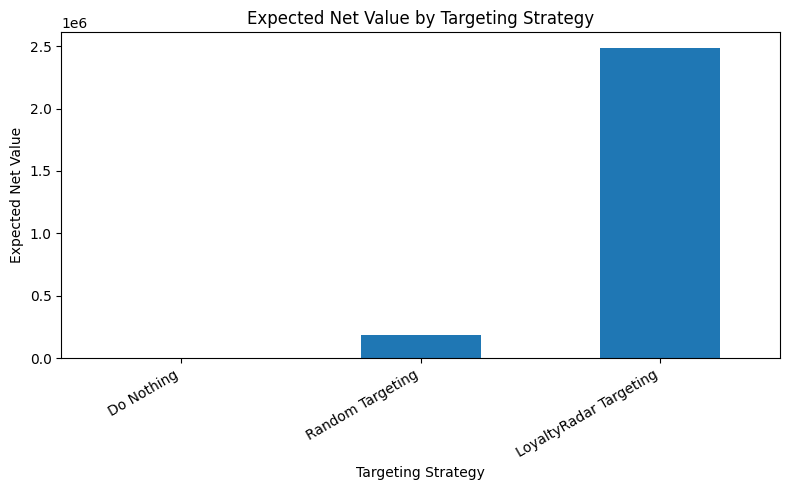

In [20]:
# Plotting expected net value by strategy

strategy_comparison.plot(
    x="strategy",
    y="expected_net_value",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Expected Net Value by Targeting Strategy")
plt.xlabel("Targeting Strategy")
plt.ylabel("Expected Net Value")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

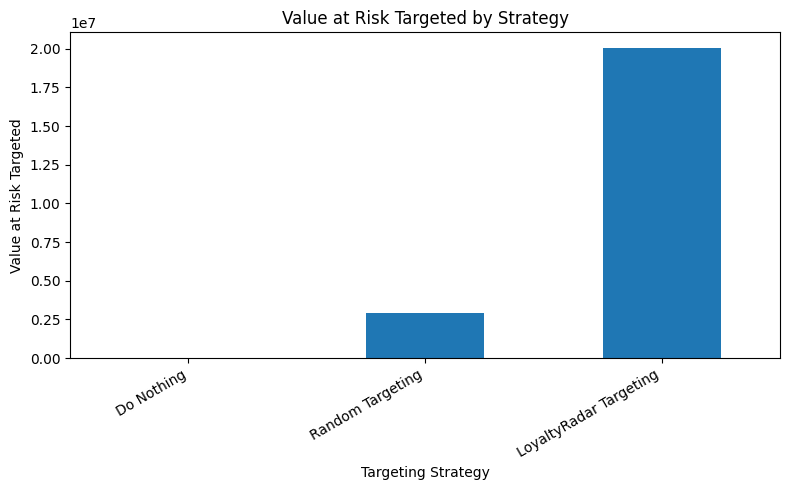

In [21]:
# Plotting value at risk targeted by strategy

strategy_comparison.plot(
    x="strategy",
    y="value_at_risk_targeted",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Value at Risk Targeted by Strategy")
plt.xlabel("Targeting Strategy")
plt.ylabel("Value at Risk Targeted")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Observation:
The strategy comparison plots visually show that LoyaltyRadar targeting performs much better than both Do Nothing and Random Targeting. LoyaltyRadar captures much higher value at risk and produces much higher expected net value while targeting the same number of customers as random targeting. This supports the business case for using behavior-based customer prioritization instead of untargeted outreach.

In [22]:
# Creating final dashboard customer table

dashboard_customer_table = campaign_table.copy()

dashboard_customer_table = dashboard_customer_table.rename(
    columns={"next_best_action_v2": "next_best_action"}
)

dashboard_customer_table = dashboard_customer_table.sort_values(
    ["loyalty_value_at_risk", "retention_priority_score", "recovery_potential_score_v2"],
    ascending=False
)

print("Dashboard customer table shape:", dashboard_customer_table.shape)
display(dashboard_customer_table.head(20))

Dashboard customer table shape: (16737, 22)


,loyalty_number,primary_segment,next_best_action,priority_band,retention_priority_score,recovery_potential_band,recovery_potential_score_v2,clv,loyalty_value_at_risk,clv_tier,loyalty_card,province,city,behavioral_churn,formal_churn,churn_status_group,active_month_rate,inactive_months,flights_last_6m,points_collector_flag,sharp_drop_flag,seasonal_flag
335,652627,Premium Drifter,Personalized premium win-back offer,Critical Priority,70,Medium Recovery Potential,40,83325.38,83325.38,Premium Value,Star,Manitoba,Winnipeg,1,1,Confirmed Churn,0.000000,24,0,0,0,0
336,844145,Premium Drifter,Personalized premium win-back offer,Critical Priority,70,Medium Recovery Potential,40,74228.52,74228.52,Premium Value,Nova,Ontario,Toronto,1,1,Confirmed Churn,0.000000,24,0,0,0,0
74,767366,Premium Drifter,Personalized premium win-back offer,Critical Priority,75,Medium Recovery Potential,50,73225.96,73225.96,Premium Value,Aurora,Quebec,Montreal,1,1,Confirmed Churn,0.166667,20,0,0,0,1
138,838263,Premium Drifter,Personalized premium win-back offer,Critical Priority,70,Medium Recovery Potential,65,67907.27,67907.27,Premium Value,Aurora,Nova Scotia,Halifax,1,0,Silent Risk,0.000000,24,0,0,0,0
337,672917,Premium Drifter,Personalized premium win-back offer,Critical Priority,70,Medium Recovery Potential,40,58166.55,58166.55,Premium Value,Star,Ontario,Toronto,1,1,Confirmed Churn,0.000000,24,0,0,0,0
139,737027,Premium Drifter,Personalized premium win-back offer,Critical Priority,70,Medium Recovery Potential,65,49221.43,49221.43,Premium Value,Nova,British Columbia,Vancouver,1,0,Silent Risk,0.000000,24,0,0,0,0
338,529331,Premium Drifter,Personalized premium win-back offer,Critical Priority,70,Medium Recovery Potential,40,49221.43,49221.43,Premium Value,Aurora,Ontario,Toronto,1,1,Confirmed Churn,0.000000,24,0,0,0,0
339,943393,Premium Drifter,Personalized premium win-back offer,Critical Priority,70,Medium Recovery Potential,40,48356.96,48356.96,Premium Value,Nova,British Columbia,Vancouver,1,1,Confirmed Churn,0.000000,24,0,0,0,0
140,257194,Premium Drifter,Personalized premium win-back offer,Critical Priority,70,Medium Recovery Potential,65,46770.95,46770.95,Premium Value,Nova,British Columbia,Vancouver,1,0,Silent Risk,0.000000,24,0,0,0,0
133,258296,Premium Drifter,Personalized premium win-back offer,Critical Priority,70,High Recovery Potential,85,44856.11,44856.11,Premium Value,Aurora,Quebec,Montreal,1,0,Silent Risk,0.291667,17,0,0,0,0


In [23]:
# Saving dashboard customer table

dashboard_customer_table.to_csv(
    DASHBOARD_DIR / "dashboard_customer_table.csv",
    index=False
)

print("Saved dashboard customer table.")

Saved dashboard customer table.


In [24]:
# Summarizing Notebook 06 results

print("NB06 SUMMARY")
print("-" * 50)

print("Dashboard data preparation completed.")
print("Total customers:", int(total_customers))
print("Total CLV:", round(total_clv, 2))
print("Total value at risk:", round(total_value_at_risk, 2))
print("Value at risk share (%):", round(total_value_at_risk / total_clv * 100, 2))

print("\nCampaign ROI simulation:")
print("Campaign customers:", int(total_campaign_customers))
print("Total campaign cost:", round(total_campaign_cost, 2))
print("Expected recovered value:", round(total_expected_recovered_value, 2))
print("Expected net value:", round(total_expected_net_value, 2))
print("Overall ROI multiple:", round(overall_roi_multiple, 2))

print("\nStrategy comparison:")
print(strategy_comparison[["strategy", "expected_net_value", "roi_multiple"]])

print("\nDashboard files saved in:")
print(DASHBOARD_DIR)

print("\nNotebook 06 completed successfully.")

NB06 SUMMARY
--------------------------------------------------
Dashboard data preparation completed.
Total customers: 16737
Total CLV: 133710161.32
Total value at risk: 20062457.87
Value at risk share (%): 15.0

Campaign ROI simulation:
Campaign customers: 2469
Total campaign cost: 106409
Expected recovered value: 2593255.32
Expected net value: 2486846.32
Overall ROI multiple: 24.37

Strategy comparison:
                 strategy  expected_net_value  roi_multiple
0              Do Nothing               0.000         0.000
1        Random Targeting          184354.262         4.733
2  LoyaltyRadar Targeting         2486846.318        24.371

Dashboard files saved in:
/content/drive/MyDrive/LoyaltyRadar/dashboard/data

Notebook 06 completed successfully.
